In [1]:
import pandas as pd
import numpy as np
import os

data_path = "../data/"
shopping_file = "customer_shopping_data.csv"
behavior_file = "ecommerce_customer_behavior.csv"
reviews_file = "womens_clothing_reviews.csv"
shopping = pd.read_csv(os.path.join(data_path, shopping_file))
behavior = pd.read_csv(os.path.join(data_path, behavior_file))
reviews = pd.read_csv(os.path.join(data_path, reviews_file))

print(" Tebrikler! Tüm veri setleri başarıyla yüklendi.")
print(f"Shopping: {shopping.shape}")
print(f"Behavior: {behavior.shape}")
print(f"Reviews: {reviews.shape}")

c:\Users\MUKADDER\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\MUKADDER\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


 Tebrikler! Tüm veri setleri başarıyla yüklendi.
Shopping: (99457, 10)
Behavior: (350, 11)
Reviews: (23486, 11)


In [3]:

def clean_columns(df):
    df.columns = (
        df.columns
        .str.lower()         
        .str.strip()         
        .str.replace(" ", "_") 
        .str.replace("-", "_") 
    )
    return df

shopping = clean_columns(shopping)
behavior = clean_columns(behavior)
reviews = clean_columns(reviews)

print(" Kolon isimleri standart hale getirildi!")
print("Shopping Kolonları:", shopping.columns.tolist())
print("\nBehavior Kolonları:", behavior.columns.tolist())
print("\nReviews Kolonları:", reviews.columns.tolist())

 Kolon isimleri standart hale getirildi!
Shopping Kolonları: ['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity', 'price', 'payment_method', 'invoice_date', 'shopping_mall']

Behavior Kolonları: ['customer_id', 'gender', 'age', 'city', 'membership_type', 'total_spend', 'items_purchased', 'average_rating', 'discount_applied', 'days_since_last_purchase', 'satisfaction_level']

Reviews Kolonları: ['unnamed:_0', 'clothing_id', 'age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name']


In [4]:

for name, df in {"Shopping": shopping, "Behavior": behavior, "Reviews": reviews}.items():
    print(f"--- {name} Eksik Veri Sayısı ---")
    print(df.isnull().sum())
    print("\n")

--- Shopping Eksik Veri Sayısı ---
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


--- Behavior Eksik Veri Sayısı ---
customer_id                 0
gender                      0
age                         0
city                        0
membership_type             0
total_spend                 0
items_purchased             0
average_rating              0
discount_applied            0
days_since_last_purchase    0
satisfaction_level          2
dtype: int64


--- Reviews Eksik Veri Sayısı ---
unnamed:_0                    0
clothing_id                   0
age                           0
title                      3810
review_text                 845
rating                        0
recommended_ind               0
positive_feedback_count       0
division_name                14
department_name              14
class_name      

In [5]:

def create_age_groups(df):
    bins = [0, 18, 25, 35, 45, 60, 100]
    labels = ["0-18", "19-25", "26-35", "36-45", "46-60", "60+"]
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
    return df

shopping = create_age_groups(shopping)
behavior = create_age_groups(behavior)
reviews = create_age_groups(reviews)

shopping['total_amount'] = shopping['price'] * shopping['quantity']
shopping['spending_segment'] = pd.qcut(shopping['total_amount'], q=3, labels=["Low", "Medium", "High"])

shopping = shopping.rename(columns={'category': 'main_category'})
behavior = behavior.rename(columns={'product_category': 'main_category'}) 
reviews = reviews.rename(columns={'class_name': 'main_category'})

print(" Özellikler üretildi ve kategoriler isimlendirildi!")

 Özellikler üretildi ve kategoriler isimlendirildi!


In [6]:

print("Behavior kolonları:", behavior.columns.tolist())
if 'product_category' in behavior.columns:
    behavior = behavior.rename(columns={'product_category': 'main_category'})
elif 'category' in behavior.columns:
    behavior = behavior.rename(columns={'category': 'main_category'})
if 'class_name' in reviews.columns:
    reviews = reviews.rename(columns={'class_name': 'main_category'})

print(" Kolon isimleri tekrar kontrol edildi ve güncellendi.")

Behavior kolonları: ['customer_id', 'gender', 'age', 'city', 'membership_type', 'total_spend', 'items_purchased', 'average_rating', 'discount_applied', 'days_since_last_purchase', 'satisfaction_level', 'age_group']
 Kolon isimleri tekrar kontrol edildi ve güncellendi.


In [7]:

shopping_summary = shopping.groupby(['age_group', 'gender', 'main_category']).agg({
    'total_amount': 'mean',
    'quantity': 'sum'
}).reset_index().rename(columns={'total_amount': 'avg_shopping_spend'})
behavior_summary = behavior.groupby(['age_group', 'gender']).agg({
    'average_rating': 'mean'
}).reset_index().rename(columns={'average_rating': 'behavior_satisfaction'})
reviews_summary = reviews.groupby(['age_group', 'main_category']).agg({
    'rating': 'mean'
}).reset_index().rename(columns={'rating': 'review_rating'})

print(" Özet tablolar başarıyla oluşturuldu!")
display(behavior_summary.head())

 Özet tablolar başarıyla oluşturuldu!


,age_group,gender,behavior_satisfaction
0,26-35,Female,4.510000
1,26-35,Male,4.305172
2,36-45,Female,3.325217
3,36-45,Male,4.600000


In [8]:

merged_df = pd.merge(shopping_summary, behavior_summary, on=['age_group', 'gender'], how='inner')
final_df = pd.merge(merged_df, reviews_summary, on=['age_group', 'main_category'], how='left')
final_df['review_rating'] = final_df['review_rating'].fillna(final_df['review_rating'].mean())
print(" MUHTEŞEM! 3 Dataset artık tek bir tabloda.")
print(f"Final Tablo Boyutu: {final_df.shape}")
display(final_df.head(10))

 MUHTEŞEM! 3 Dataset artık tek bir tabloda.
Final Tablo Boyutu: (32, 7)


,age_group,gender,main_category,avg_shopping_spend,quantity,behavior_satisfaction,review_rating
0,26-35,Female,Books,172.253052,1697,4.510000,NaN
1,26-35,Female,Clothing,3296.521212,11977,4.510000,NaN
2,26-35,Female,Cosmetics,450.405751,5226,4.510000,NaN
3,26-35,Female,Food & Beverage,59.080219,5000,4.510000,NaN
4,26-35,Female,Shoes,6519.610451,3293,4.510000,NaN
5,26-35,Female,Souvenir,132.107376,1789,4.510000,NaN
6,26-35,Female,Technology,10872.061329,1700,4.510000,NaN
7,26-35,Female,Toys,388.664226,3587,4.510000,NaN
8,26-35,Male,Books,165.439669,1076,4.305172,NaN
9,26-35,Male,Clothing,3289.659916,7843,4.305172,NaN


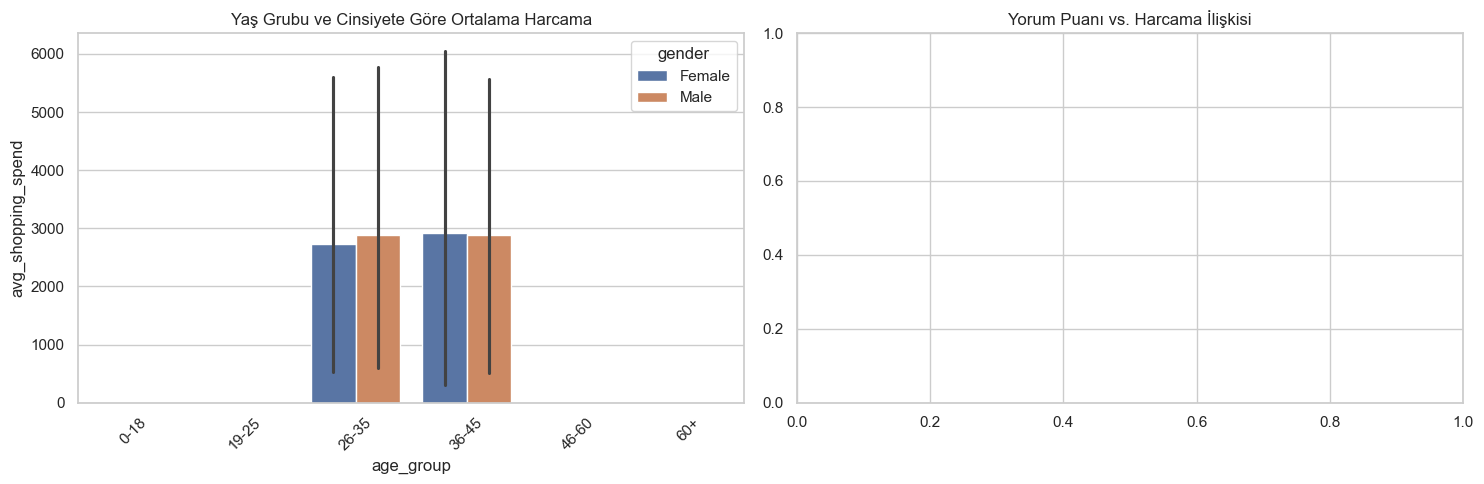

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=final_df, x='age_group', y='avg_shopping_spend', hue='gender')
plt.title('Yaş Grubu ve Cinsiyete Göre Ortalama Harcama')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.scatterplot(data=final_df, x='review_rating', y='avg_shopping_spend', hue='age_group', s=100)
plt.title('Yorum Puanı vs. Harcama İlişkisi')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

median_spend = final_df['avg_shopping_spend'].median()
final_df['spend_level'] = final_df['avg_shopping_spend'].apply(lambda x: 1 if x > median_spend else 0)

le = LabelEncoder()
model_data = final_df.copy()
model_data['gender'] = le.fit_transform(model_data['gender'])
model_data['main_category'] = le.fit_transform(model_data['main_category'])
model_data['age_group'] = le.fit_transform(model_data['age_group'].astype(str))

X = model_data[['age_group', 'gender', 'main_category', 'behavior_satisfaction', 'review_rating']]
y = model_data['spend_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(" Model eğitildi! Şimdi sonuçlara bakalım.")

 Model eğitildi! Şimdi sonuçlara bakalım.


--- MODEL BAŞARI RAPORU ---
              precision    recall  f1-score   support

           0       0.33      0.25      0.29         4
           1       0.25      0.33      0.29         3

    accuracy                           0.29         7
   macro avg       0.29      0.29      0.29         7
weighted avg       0.30      0.29      0.29         7



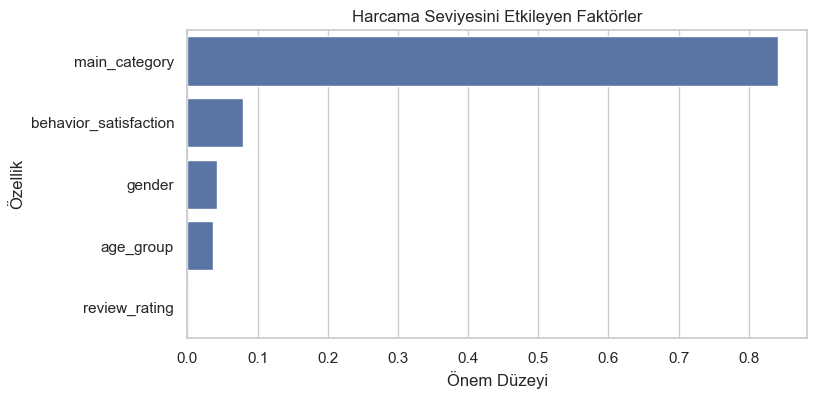

In [11]:

y_pred = model.predict(X_test)

print("--- MODEL BAŞARI RAPORU ---")
print(classification_report(y_test, y_pred))

importance = pd.DataFrame({
    'Özellik': X.columns,
    'Önem Düzeyi': model.feature_importances_
}).sort_values(by='Önem Düzeyi', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance, x='Önem Düzeyi', y='Özellik')
plt.title('Harcama Seviyesini Etkileyen Faktörler')
plt.show()

In [12]:

df_final_pro = shopping.copy()
behavior_map = behavior.groupby(['age_group', 'gender'])['average_rating'].mean().to_dict()
df_final_pro['predicted_satisfaction'] = df_final_pro.set_index(['age_group', 'gender']).index.map(behavior_map)
reviews_map = reviews.groupby(['age_group', 'main_category'])['rating'].mean().to_dict()
df_final_pro['category_rating'] = df_final_pro.set_index(['age_group', 'main_category']).index.map(reviews_map)
df_final_pro['predicted_satisfaction'] = df_final_pro['predicted_satisfaction'].fillna(df_final_pro['predicted_satisfaction'].mean())
df_final_pro['category_rating'] = df_final_pro['category_rating'].fillna(df_final_pro['category_rating'].mean())

print(f" Profesyonel veri seti hazır! Satır sayısı: {len(df_final_pro)}")
display(df_final_pro.head())

 Profesyonel veri seti hazır! Satır sayısı: 99457


,invoice_no,customer_id,gender,age,main_category,quantity,price,payment_method,invoice_date,shopping_mall,age_group,total_amount,spending_segment,predicted_satisfaction,category_rating
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon,26-35,7502.00,High,4.510000,NaN
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,19-25,5401.53,High,4.125236,NaN
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity,19-25,300.08,Medium,4.125236,NaN
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM,60+,15004.25,High,4.125236,NaN
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon,46-60,242.40,Low,4.125236,NaN


In [13]:
from sklearn.ensemble import RandomForestClassifier
df_final_pro['spending_segment'] = pd.qcut(df_final_pro['total_amount'], q=3, labels=[0, 1, 2])
X = pd.get_dummies(df_final_pro[['age_group', 'gender', 'main_category', 'predicted_satisfaction', 'category_rating']])
y = df_final_pro['spending_segment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pro = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_pro.fit(X_train, y_train)
print(" 99,000 satırlık profesyonel model eğitildi!")

 99,000 satırlık profesyonel model eğitildi!


C:\Users\MUKADDER\AppData\Local\Temp\ipykernel_26088\137903214.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_pro['predicted_satisfaction'].fillna(df_pro['predicted_satisfaction'].mean(), inplace=True)
C:\Users\MUKADDER\AppData\Local\Temp\ipykernel_26088\137903214.py:10: ChainedAssignmentError: A value is being set on a copy 

--- ANALİZ ÖZETİ (99457 Satır) ---
       total_amount  predicted_satisfaction  category_rating
count  99457.000000            38495.000000              0.0
mean    2528.789268                4.125236              NaN
std     4222.475781                0.539271              NaN
min        5.230000                3.325217              NaN
25%      136.350000                3.325217              NaN
50%      600.170000                4.305172              NaN
75%     2700.720000                4.510000              NaN
max    26250.000000                4.600000              NaN


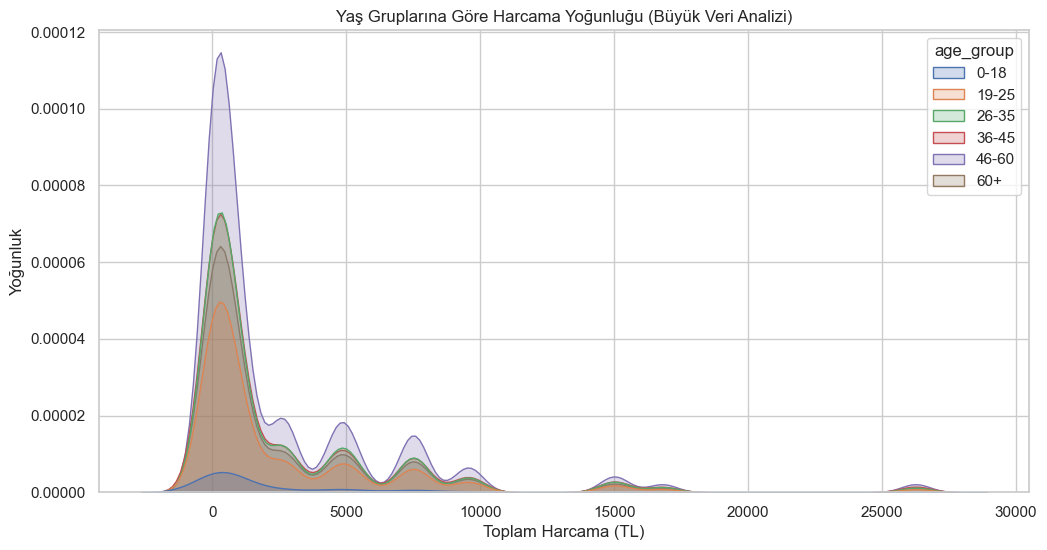

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_pro = shopping.copy()
behavior_map = behavior.groupby(['age_group', 'gender'])['average_rating'].mean().to_dict()
reviews_map = reviews.groupby(['age_group', 'main_category'])['rating'].mean().to_dict()
df_pro['predicted_satisfaction'] = df_pro.set_index(['age_group', 'gender']).index.map(behavior_map)
df_pro['category_rating'] = df_pro.set_index(['age_group', 'main_category']).index.map(reviews_map)
df_pro['predicted_satisfaction'].fillna(df_pro['predicted_satisfaction'].mean(), inplace=True)
df_pro['category_rating'].fillna(df_pro['category_rating'].mean(), inplace=True)
print(f"--- ANALİZ ÖZETİ ({len(df_pro)} Satır) ---")
print(df_pro[['total_amount', 'predicted_satisfaction', 'category_rating']].describe())
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_pro, x='total_amount', hue='age_group', fill=True)
plt.title('Yaş Gruplarına Göre Harcama Yoğunluğu (Büyük Veri Analizi)')
plt.xlabel('Toplam Harcama (TL)')
plt.ylabel('Yoğunluk')
plt.show()

In [15]:
import pandas as pd
print("--- MEVCUT KOLONLARINIZ ---")
print(df.columns.tolist())
print("---------------------------")
cat_candidates = [c for c in df.columns if any(x in c.lower() for x in ['cat', 'class', 'type'])]

if not cat_candidates:
    cat_candidates = df.select_dtypes(include=['object']).columns.tolist()
if cat_candidates:
    final_cat_col = cat_candidates[0]
    print(f" Bulunan en mantıklı kategori kolonu: '{final_cat_col}'")
    if 'age_group' not in df.columns:
        bins = [0, 18, 25, 35, 45, 60, 100]
        labels = ["0-18", "19-25", "26-35", "36-45", "46-60", "60+"]
        df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
    age_cat_summary = df.groupby(['age_group', final_cat_col], observed=True).size().reset_index(name='islem_sayisi')
    age_cat_summary = age_cat_summary.rename(columns={final_cat_col: 'category'})
    display(age_cat_summary.sort_values(by=['age_group', 'islem_sayisi'], ascending=[True, False]).head(10))
else:
    print(" Maalesef hiçbir kategori benzeri kolon bulunamadı. Lütfen kolon listesini kontrol et!")

--- MEVCUT KOLONLARINIZ ---
['unnamed:_0', 'clothing_id', 'age', 'title', 'review_text', 'rating', 'recommended_ind', 'positive_feedback_count', 'division_name', 'department_name', 'class_name', 'age_group']
---------------------------
 Bulunan en mantıklı kategori kolonu: 'class_name'


,age_group,category,islem_sayisi
0,0-18,Dresses,2
1,0-18,Knits,1
2,0-18,Skirts,1
4,19-25,Dresses,355
9,19-25,Knits,232
3,19-25,Blouses,145
18,19-25,Sweaters,68
5,19-25,Fine gauge,57
14,19-25,Pants,57
16,19-25,Skirts,55


In [16]:
import streamlit as st
import pandas as pd
import plotly.express as px
@st.cache_data
def load_data():
    df = pd.read_csv("data/customer_shopping_data.csv")
    df.columns = df.columns.str.strip().str.lower()
    df['total_amount'] = df['price'] * df['quantity']
    bins = [0, 18, 25, 35, 45, 60, 100]
    labels = ["0-18", "19-25", "26-35", "36-45", "46-60", "60+"]
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
    
    return df

try:
    df = load_data()

    st.title(" Yaş Grupları Arası Kategori Düellosu")
    st.markdown("---") 
    col_a, col_b = st.columns(2)
    with col_a:
        yas_1 = st.selectbox("Birinci Yaş Grubu Seçin", df['age_group'].unique(), index=0)
        df_1 = df[df['age_group'] == yas_1]
        kat_1 = df_1['category'].value_counts().reset_index()
        kat_1.columns = ['kategori', 'adet']
        st.write(f" **{yas_1} Yaş** Tercihleri")
        fig1 = px.bar(kat_1, x='kategori', y='adet', color='kategori', text_auto=True)
        st.plotly_chart(fig1, use_container_width=True)

    with col_b:
        yas_2 = st.selectbox("İkinci Yaş Grubu Seçin", df['age_group'].unique(), index=len(df['age_group'].unique())-1)
        df_2 = df[df['age_group'] == yas_2]
        kat_2 = df_2['category'].value_counts().reset_index()
        kat_2.columns = ['kategori', 'adet']
        
        st.write(f" **{yas_2} Yaş** Tercihleri")
        fig2 = px.bar(kat_2, x='kategori', y='adet', color='kategori', text_auto=True)
        st.plotly_chart(fig2, use_container_width=True)

except Exception as e:
    st.error(f" Bir hata oluştu: {e}")

2026-05-16 14:46:09.720 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-16 14:46:09.725 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-16 14:46:09.729 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 14:46:09.805 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 14:46:11.613 
  command:

    streamlit run c:\Users\MUKADDER\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-16 14:46:11.613 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-16 14:46:11.613 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runni